# Dataset exploration & comparison — KarmaDock seminar (team002)

Compares the inputs behind each pipeline: the **prototype** split, **PDBBind v2020**,
the **LP-PDBBind** leak-proof split, and the **curated** data surviving preprocessing.
Drives the data-side story for the report (sizes, leakage, chemistry, attrition, failures).

In [1]:
import os, glob
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, QED
from rdkit import RDLogger; RDLogger.DisableLog('rdApp.*')  # silence kekulize warnings here

LP_CSV    = os.environ.get('LP_CSV', os.path.expanduser('~/run/data/lp_PDBBind.csv'))
PROTO_TRAIN = os.environ.get('PROTO_TRAIN_CSV', '')
PROTO_TEST  = os.environ.get('PROTO_TEST_CSV', '')
BASE      = os.path.expanduser(os.environ.get('KD_BASE', '~/run'))
SAMPLE    = int(os.environ.get('SAMPLE', '5000'))   # cap per group for ligand-property calc

lp = pd.read_csv(LP_CSV, index_col=0) if os.path.isfile(LP_CSV) else None
if lp is not None:
    lp.index = lp.index.astype(str)
    print('LP-PDBBind rows:', len(lp), '| columns:', list(lp.columns))
else:
    print('LP_PDBBind.csv NOT found at', LP_CSV, '-> LP-based cells will skip')

LP-PDBBind rows: 19443 | columns: ['header', 'smiles', 'category', 'seq', 'resolution', 'date', 'type', 'new_split', 'CL1', 'CL2', 'CL3', 'remove_for_balancing_val', 'kd/ki', 'value', 'covalent']


## 1. Dataset sizes & composition

PDBBind v2020 by source set (general/refined/core), the LP-PDBBind `new_split`, and the
prototype split. PDBBind v2020 has 19,443 complexes total; LP-PDBBind re-splits them into
train/val/test (+discarded) to remove leakage.

,dataset,n
0,PDBBind v2020 (general),14108
1,PDBBind v2020 (refined),5050
2,PDBBind v2020 (core),285
3,LP-PDBBind train,11513
4,LP-PDBBind val,2422
5,LP-PDBBind test,4860
6,LP-PDBBind discarded,648
7,prototype train,712
8,prototype test,118


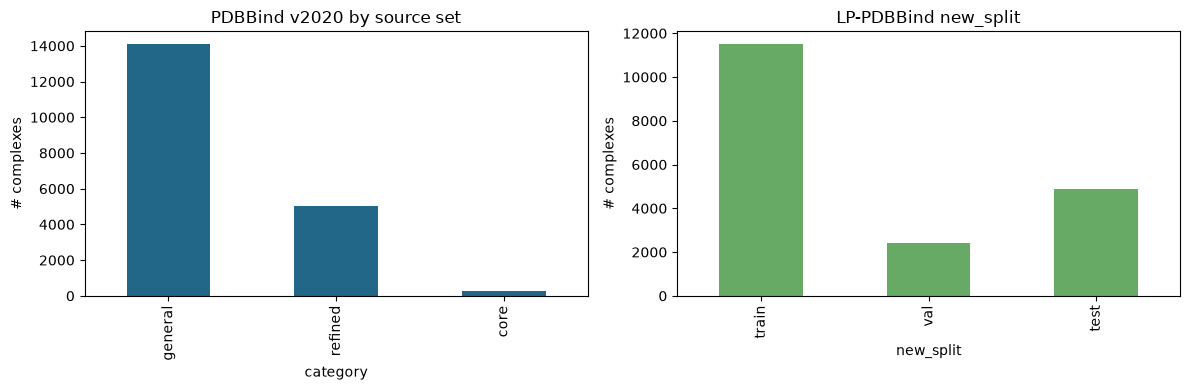

In [2]:
def proto_n(csv):
    return (len(pd.read_csv(csv)) if os.path.isfile(csv) else None)

rows = []
if lp is not None:
    cat = lp['category'].value_counts().to_dict() if 'category' in lp else {}
    rows.append({'dataset': 'PDBBind v2020 (general)', 'n': cat.get('general')})
    rows.append({'dataset': 'PDBBind v2020 (refined)', 'n': cat.get('refined')})
    rows.append({'dataset': 'PDBBind v2020 (core)',    'n': cat.get('core')})
    sp = lp['new_split'].value_counts().to_dict()
    for k in ['train','val','test']:
        rows.append({'dataset': f'LP-PDBBind {k}', 'n': sp.get(k)})
    rows.append({'dataset': 'LP-PDBBind discarded', 'n': int(lp['new_split'].isna().sum() + (lp['new_split']=='').sum())})
rows.append({'dataset': 'prototype train', 'n': proto_n(PROTO_TRAIN)})
rows.append({'dataset': 'prototype test',  'n': proto_n(PROTO_TEST)})
display(pd.DataFrame(rows))

if lp is not None:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    lp['category'].value_counts().plot.bar(ax=ax[0], title='PDBBind v2020 by source set', color='#268')
    lp['new_split'].value_counts().reindex(['train','val','test']).plot.bar(ax=ax[1], title='LP-PDBBind new_split', color='#6a6')
    for a in ax: a.set_ylabel('# complexes')
    plt.tight_layout(); plt.show()

## 2. Clean levels & covalent (LP-PDBBind)

CL1 ⊂ ... wait: CL3 ⊂ CL2 ⊂ CL1 (progressively stricter cleaning). The seminar P4/P5 use
the paper protocol: **train/val on CL1, test on CL2, non-covalent**. Here is the membership.

In [3]:
if lp is not None:
    tab = []
    for sp in ['train','val','test']:
        sub = lp[lp.new_split==sp]
        row = {'split': sp, 'all': len(sub), 'covalent': int(sub['covalent'].sum()) if 'covalent' in sub else None}
        for cl in ['CL1','CL2','CL3']:
            if cl in sub:
                row[f'{cl} & noncov'] = int((sub[cl].astype(bool) & ~sub['covalent'].astype(bool)).sum())
        tab.append(row)
    display(pd.DataFrame(tab))
    print('P4/P5 train = CL1&noncov train ; test = CL2&noncov test (paper protocol).')
else:
    print('skip: LP csv not loaded')

,split,all,covalent,CL1 & noncov,CL2 & noncov,CL3 & noncov
0,train,11513,685,7393,4345,2280
1,val,2422,104,1891,958,557
2,test,4860,102,4250,2171,1348


P4/P5 train = CL1&noncov train ; test = CL2&noncov test (paper protocol).


## 3. Train/test leakage (direct PDB-id overlap)

The motivation for LP-PDBBind: the prototype split can share the same deposited structure
between train and test (inflates scores); LP-PDBBind has **zero** direct overlap by design.

In [4]:
def codes(csv, col=None):
    if not csv or not os.path.isfile(csv): return None
    c = pd.read_csv(csv); col = col or ('ligand_file_name' if 'ligand_file_name' in c.columns else c.columns[0])
    return set(str(v).split('_')[0].lower() for v in c[col])

rows = []
pt, pte = codes(PROTO_TRAIN), codes(PROTO_TEST)
if pt and pte:
    rows.append({'split':'prototype', 'train':len(pt), 'test':len(pte), 'DIRECT_LEAKS':len(pt&pte)})
if lp is not None:
    tr = set(lp[lp.new_split=='train'].index.str.lower()); te = set(lp[lp.new_split=='test'].index.str.lower())
    rows.append({'split':'LP-PDBBind', 'train':len(tr), 'test':len(te), 'DIRECT_LEAKS':len(tr&te)})
display(pd.DataFrame(rows) if rows else 'no split CSVs available')

,split,train,test,DIRECT_LEAKS
0,prototype,500,50,0
1,LP-PDBBind,11513,4860,0


## 4. Ligand-property distributions

From the ligand SMILES: molecular weight, heavy-atom count, rotatable bonds, QED, aromatic
rings. The KarmaDock paper shows docking success depends on **heavy atoms / rotatable bonds**
(ligand flexibility), so these distributions explain part of the cross-dataset difficulty.
Computed on up to `SAMPLE` molecules per group for speed.

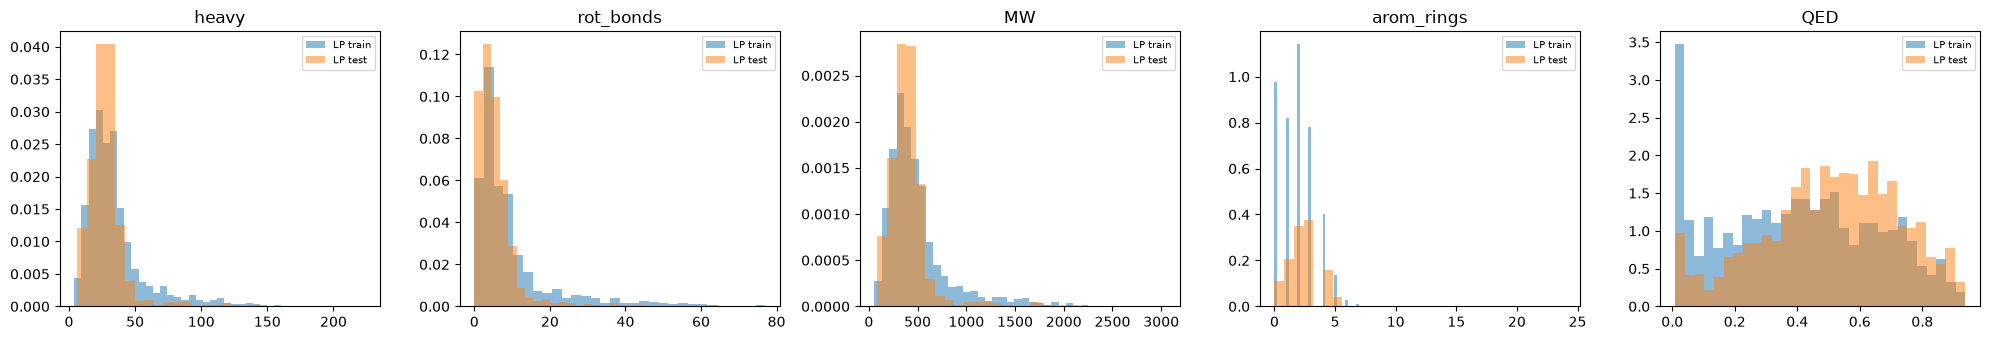

LP train                                  LP test                    \
        heavy rot_bonds     MW arom_rings  QED   heavy rot_bonds      MW   
mean     34.4     10.06  495.5       1.85  0.4   28.34       5.8  406.20   
50%      29.0      6.00  408.4       2.00  0.4   27.00       4.0  379.65   

                       
     arom_rings   QED  
mean       2.36  0.51  
50%        2.00  0.52

In [5]:
def props_from_smiles(smis):
    recs = []
    for smi in smis:
        if not isinstance(smi, str) or not smi: continue
        m = Chem.MolFromSmiles(smi)
        if m is None: continue
        recs.append({'MW': Descriptors.MolWt(m), 'heavy': m.GetNumHeavyAtoms(),
                     'rot_bonds': rdMolDescriptors.CalcNumRotatableBonds(m),
                     'arom_rings': rdMolDescriptors.CalcNumAromaticRings(m),
                     'QED': QED.qed(m)})
    return pd.DataFrame(recs)

groups = {}
if lp is not None and 'smiles' in lp.columns:
    for sp in ['train','test']:
        s = lp[lp.new_split==sp]['smiles'].dropna()
        if len(s) > SAMPLE: s = s.sample(SAMPLE, random_state=0)
        groups[f'LP {sp}'] = props_from_smiles(s)
props = {k: v for k, v in groups.items() if len(v)}
if props:
    fields = ['heavy','rot_bonds','MW','arom_rings','QED']
    fig, ax = plt.subplots(1, len(fields), figsize=(4*len(fields), 3.5))
    for j, f in enumerate(fields):
        for k, df in props.items(): ax[j].hist(df[f], bins=30, alpha=0.5, label=k, density=True)
        ax[j].set_title(f); ax[j].legend(fontsize=7)
    plt.tight_layout(); plt.show()
    display(pd.concat({k: v[fields].describe().loc[['mean','50%']] for k, v in props.items()}, axis=1).round(2))
else:
    print('skip: no SMILES available')

## 5. Protein-type composition (LP-PDBBind)

Coarse protein `type` per split — shows whether train and test cover the same protein space.

new_split,train,val,test
type,,,
hydrolase,3810,318,1375
other,2739,396,131
transferase,2134,1225,1825
transcription,579,52,298
transport,416,35,83
oxidoreductase,315,52,182
ligase,313,34,90
lyase,306,69,462
viral,184,18,53


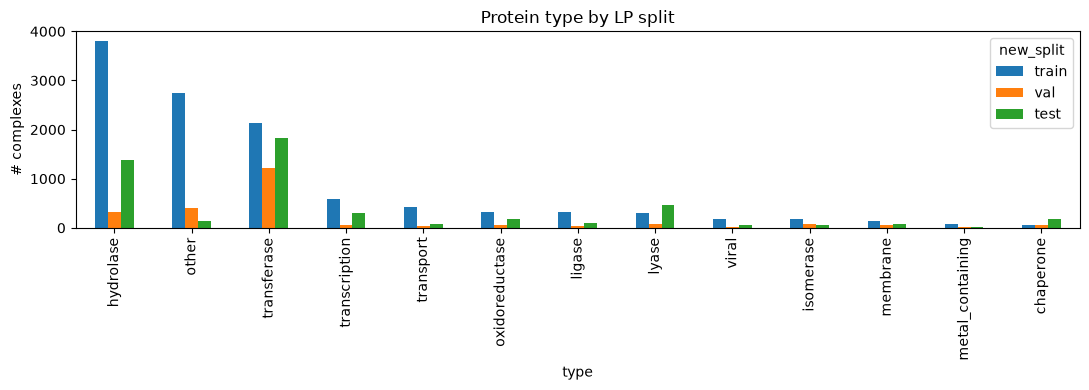

In [6]:
if lp is not None and 'type' in lp.columns:
    ct = lp.pivot_table(index='type', columns='new_split', values='smiles', aggfunc='count', fill_value=0)
    ct = ct[[c for c in ['train','val','test'] if c in ct.columns]].sort_values('train', ascending=False)
    display(ct)
    ct.plot.bar(figsize=(11,4), title='Protein type by LP split'); plt.ylabel('# complexes'); plt.tight_layout(); plt.show()
else:
    print('skip: no type column')

## 6. Binding-affinity distribution

Affinity label per split (LP `value` = pK; prototype `Log Binding Affinity`). A label shift
between train and test would be another source of difficulty.

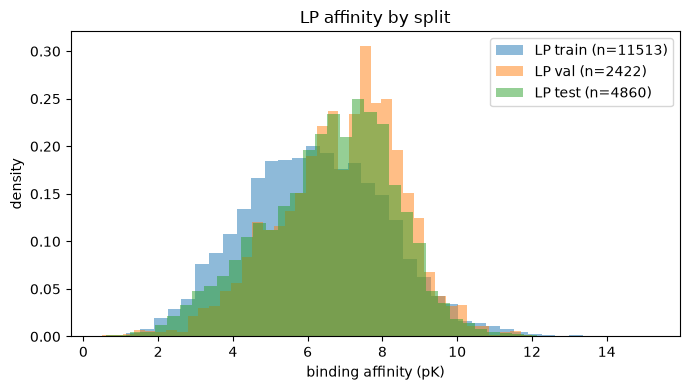

In [7]:
if lp is not None and 'value' in lp.columns:
    fig, ax = plt.subplots(figsize=(7,4))
    for sp in ['train','val','test']:
        v = pd.to_numeric(lp[lp.new_split==sp]['value'], errors='coerce').dropna()
        if len(v): ax.hist(v, bins=40, alpha=0.5, label=f'LP {sp} (n={len(v)})', density=True)
    ax.set_xlabel('binding affinity (pK)'); ax.set_ylabel('density'); ax.set_title('LP affinity by split'); ax.legend()
    plt.tight_layout(); plt.show()
else:
    print('skip: no value column')

## 7. Preprocessing attrition (curated survivors)

KarmaDock's `generate_graph.py` drops complexes whose ligand SDF can't be RDKit-sanitised
(kekulisation / valence errors in PDBBind's files). Here is how many `.dgl` graphs survived
per split vs the input count. Needs the cluster graph dirs (`KD_BASE/work/graphs/<split>`).

In [8]:
def csv_ids(path):
    if not os.path.isfile(path): return None
    c = pd.read_csv(path); col = 'ligand_file_name' if 'ligand_file_name' in c.columns else c.columns[0]
    return set(str(v).replace('_ligand_refined.sdf','').replace('_ligand.sdf','') for v in c[col])

def graph_ids(d):
    return set(os.path.basename(f)[:-4] for f in glob.glob(os.path.join(d, '*.dgl'))) if os.path.isdir(d) else None

splits = {
  'lp_train': (os.path.join(BASE,'data','lp','lp_train.csv'),  os.path.join(BASE,'work','graphs','lp_train')),
  'lp_val':   (os.path.join(BASE,'data','lp','lp_val.csv'),    os.path.join(BASE,'work','graphs','lp_val')),
  'lp_test':  (os.path.join(BASE,'data','lp','lp_test.csv'),   os.path.join(BASE,'work','graphs','lp_test')),
  'proto_train': (PROTO_TRAIN, os.path.join(BASE,'work','graphs','proto_train')),
  'proto_test':  (PROTO_TEST,  os.path.join(BASE,'work','graphs','proto_test')),
}
rows = []
KEPT = {}
for name, (csv, gdir) in splits.items():
    ids = csv_ids(csv); kept = graph_ids(gdir)
    if ids is None or kept is None:
        rows.append({'split': name, 'status': 'inputs not found (skipped)'}); continue
    KEPT[name] = (ids, kept)
    rows.append({'split': name, 'input': len(ids), 'kept(.dgl)': len(kept&ids),
                 'dropped': len(ids-kept), 'kept_%': round(100*len(kept&ids)/max(len(ids),1),1)})
display(pd.DataFrame(rows))

,split,status
0,lp_train,inputs not found (skipped)
1,lp_val,inputs not found (skipped)
2,lp_test,inputs not found (skipped)
3,proto_train,inputs not found (skipped)
4,proto_test,inputs not found (skipped)


## 8. Failure analysis — dropped vs kept ligands

Do the complexes lost to sanitisation differ chemically from those kept? Comparing aromatic
rings / heavy atoms / rotatable bonds of DROPPED vs KEPT ligands (mapped to SMILES via
LP-PDBBind) tells us whether the ~15% loss is a random or a systematic (e.g. more aromatic)
bias that could skew results. Needs section 7's graph dirs + the LP csv.

In [9]:
if lp is not None and 'smiles' in lp.columns and KEPT:
    for name, (ids, kept) in KEPT.items():
        if not name.startswith('lp_'): continue   # need SMILES mapping (LP ids)
        drop_ids = [i for i in (ids - kept) if i in lp.index]
        keep_ids = [i for i in (ids & kept) if i in lp.index]
        if not drop_ids: print(f'{name}: 0 dropped'); continue
        pd_drop = props_from_smiles(lp.loc[drop_ids, 'smiles'])
        pk = keep_ids if len(keep_ids) <= SAMPLE else list(pd.Series(keep_ids).sample(SAMPLE, random_state=0))
        pd_keep = props_from_smiles(lp.loc[pk, 'smiles'])
        cmp = pd.DataFrame({'dropped_mean': pd_drop.mean(), 'kept_mean': pd_keep.mean()}).round(2)
        cmp['delta'] = (cmp['dropped_mean'] - cmp['kept_mean']).round(2)
        print(f'=== {name}: dropped (n={len(pd_drop)}) vs kept (n={len(pd_keep)}) ligand properties ===')
        display(cmp)
else:
    print('skip: need LP csv + section-7 graph dirs')

skip: need LP csv + section-7 graph dirs


## 9. Summary

Programmatic recap of the dataset landscape (sizes, leakage, attrition) for the report.

In [10]:
lines = []
if lp is not None:
    sp = lp['new_split'].value_counts().to_dict()
    lines.append(f"PDBBind v2020 total = {len(lp)} ; LP split train/val/test = {sp.get('train')}/{sp.get('val')}/{sp.get('test')}")
    for s in ['train','val','test']:
        sub = lp[lp.new_split==s]
        if 'CL1' in sub and 'covalent' in sub:
            cl = 'CL1' if s!='test' else 'CL2'
            n = int((sub[cl].astype(bool) & ~sub['covalent'].astype(bool)).sum())
            lines.append(f'  {s}: {cl}&noncov used by P4/P5 = {n}')
for name in ['lp_train','lp_val','lp_test']:
    if name in KEPT:
        ids, kept = KEPT[name]; lines.append(f'  {name}: {len(kept&ids)}/{len(ids)} survived preprocessing')
print('\n'.join(lines) if lines else 'No datasets loaded.')

PDBBind v2020 total = 19443 ; LP split train/val/test = 11513/2422/4860
  train: CL1&noncov used by P4/P5 = 7393
  val: CL1&noncov used by P4/P5 = 1891
  test: CL2&noncov used by P4/P5 = 2171
